<h3>Improving F1-score via Enhanced Feature Selection/Engineering

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from evaluate_binary_classifier import *

import joblib

from scipy.stats import randint, uniform, loguniform

from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
INTERIM_DATA_DIR = DATA_DIR / "interim"
RAW_DATA_DIR = DATA_DIR / "raw"

In [2]:
# Load the data and convert yes/no to binary:

with open(INTERIM_DATA_DIR / "X_test_raw.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(INTERIM_DATA_DIR / "y_test_raw.pkl", "rb") as f:
    y_test = pickle.load(f)

with open(INTERIM_DATA_DIR / "X_train_raw.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(INTERIM_DATA_DIR / "y_train_raw.pkl", "rb") as f:
    y_train = pickle.load(f)

yes_no_map = {"no": 0, "yes": 1}

y_train = y_train.map(yes_no_map).astype("int8")
y_test = y_test.map(yes_no_map).astype("int8")

In [4]:
# Imputation:

def filter_unknown_rows(
    X,
    y,
    columns=("job", "education"),
    unknown_value="unknown"
):
    """
    Remove rows where any selected column contains:
    - NaN / missing value
    - an empty string
    - whitespace only
    - the value 'unknown'

    The same rows are removed from X and y.
    """

    X = X.copy()
    y = y.copy()

    if len(X) != len(y):
        raise ValueError(
            f"X and y have different lengths: {len(X)} and {len(y)}."
        )

    if not X.index.equals(y.index):
        raise ValueError(
            "X and y indexes are not aligned."
        )

    missing_columns = [
        column
        for column in columns
        if column not in X.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Columns not found in X: {missing_columns}"
        )

    keep_mask = pd.Series(
        True,
        index=X.index
    )

    for column in columns:
        cleaned_column = (
            X[column]
            .astype("string")
            .str.strip()
            .str.lower()
        )

        keep_mask &= cleaned_column.notna()
        keep_mask &= cleaned_column.ne("")
        keep_mask &= cleaned_column.ne(
            unknown_value.lower()
        )

    X_filtered = X.loc[keep_mask].copy()
    y_filtered = y.loc[keep_mask].copy()

    return X_filtered, y_filtered

# Apply independently to train and test
X_train, y_train = filter_unknown_rows(
    X_train,
    y_train,
    columns=("job", "education")
)

X_test, y_test = filter_unknown_rows(
    X_test,
    y_test,
    columns=("job", "education")
)

# Reset indexes after deleting rows
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("\nFiltered training shape:", X_train.shape)
print("Filtered test shape:", X_test.shape)

print(
    "Training X/y aligned:",
    len(X_train) == len(y_train)
)

print("Test X/y aligned:",len(X_test) == len(y_test))


Filtered training shape: (26811, 13)
Filtered test shape: (11527, 13)
Training X/y aligned: True
Test X/y aligned: True


<h4>Preprocessing-only Pipeline (no sampling or modelling)

In [5]:
# Customer transformers to be used in the pipeline

# Feature dropping (custom transformer adapted from the previous notebooks)

class FeatureDropper(BaseEstimator, TransformerMixin):
    """
    Delete selected dataframe columns.
    """

    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "FeatureDropper requires a pandas DataFrame."
            )

        self.columns_ = list(self.columns or [])

        missing_columns = [
            column
            for column in self.columns_
            if column not in X.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Columns not found: {missing_columns}"
            )

        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "FeatureDropper requires a pandas DataFrame."
            )

        return X.drop(
            columns=self.columns_
        ).copy()


features_to_remove = [
    "age",
    "balance",
    "campaign",
    "default",
    "loan",
    "contact"
]

# Cyclical encoding of day and month columns:

class CyclicalDateEncoder(BaseEstimator, TransformerMixin):
    """
    Convert day and month into sine/cosine cyclical features.

    Creates:
    - day_sin
    - day_cos
    - month_sin
    - month_cos

    The original day and month columns are then removed.
    """

    def __init__(
        self,
        day_column="day",
        month_column="month",
        drop_original=True
    ):
        self.day_column = day_column
        self.month_column = month_column
        self.drop_original = drop_original

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CyclicalDateEncoder requires a pandas DataFrame."
            )

        required_columns = [
            self.day_column,
            self.month_column
        ]

        missing_columns = [
            column
            for column in required_columns
            if column not in X.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Missing cyclical columns: {missing_columns}"
            )

        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "CyclicalDateEncoder requires a pandas DataFrame."
            )

        X = X.copy()

        month_mapping = {
            "jan": 1,
            "feb": 2,
            "mar": 3,
            "apr": 4,
            "may": 5,
            "jun": 6,
            "jul": 7,
            "aug": 8,
            "sep": 9,
            "oct": 10,
            "nov": 11,
            "dec": 12
        }

        day_numeric = pd.to_numeric(
            X[self.day_column],
            errors="coerce"
        )

        if pd.api.types.is_numeric_dtype(
            X[self.month_column]
        ):
            month_numeric = pd.to_numeric(
                X[self.month_column],
                errors="coerce"
            )
        else:
            month_numeric = (
                X[self.month_column]
                .astype("string")
                .str.strip()
                .str.lower()
                .map(month_mapping)
            )

        # Day cycle: 1 to 31
        X["day_sin"] = np.sin(
            2 * np.pi * (day_numeric - 1) / 31
        )

        X["day_cos"] = np.cos(
            2 * np.pi * (day_numeric - 1) / 31
        )

        # Month cycle: 1 to 12
        X["month_sin"] = np.sin(
            2 * np.pi * (month_numeric - 1) / 12
        )

        X["month_cos"] = np.cos(
            2 * np.pi * (month_numeric - 1) / 12
        )

        if self.drop_original:
            X = X.drop(
                columns=[
                    self.day_column,
                    self.month_column
                ]
            )

        return X


numeric_features = [
    "duration",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]

housing_features = [
    "housing"
]

one_hot_features = [
    "job",
    "marital",
    "education",
]

In [8]:
# Pipeline components:

numeric_pipeline = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "robust_scaler",
            RobustScaler()
        )
    ]
)

housing_pipeline = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "ordinal_encoder",
            OrdinalEncoder(
                categories=[["no", "yes"]],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

one_hot_pipeline = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

# Combine the above components
column_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "housing",
            housing_pipeline,
            housing_features
        ),
        (
            "categorical",
            one_hot_pipeline,
            one_hot_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [16]:
# Pipeline which carries out feature removal/engineering, then returns the transformed data without any modelling:

preprocessing_pipeline = ImbPipeline(
    steps=[
        (
            "feature_selection",
            FeatureDropper(
                columns=features_to_remove
            )
        ),
        (
            "cyclical_encoding",
            CyclicalDateEncoder(
                day_column="day",
                month_column="month",
                drop_original=True
            )
        ),
        (
            "preprocessor",
            column_preprocessor
        )
    ]
)

# The pipeline creates an array with no feature column titles. We need to extract them
def get_processed_feature_names(fitted_preprocessing_pipeline):
    """
    Return output feature names from the fitted preprocessing pipeline.
    """
    return fitted_preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [19]:
# Fit the preprocessing pipeline on training data and transform X_train
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)

# Alignment check with y_train
if X_train_processed.shape[0] != len(y_train):
    raise ValueError(
        f"Row mismatch: X_train_processed has {X_train_processed.shape[0]} rows, "
        f"but y_train has {len(y_train)} rows."
    )

print("X_train_processed shape:", X_train_processed.shape)
print("y_train length:", len(y_train))
print("Aligned:", X_train_processed.shape[0] == len(y_train))

processed_feature_names = get_processed_feature_names(preprocessing_pipeline)
print("Number of processed features:", len(processed_feature_names))
print(processed_feature_names)

X_train_processed shape: (26811, 23)
y_train length: 26811
Aligned: True
Number of processed features: 23
['duration' 'day_sin' 'day_cos' 'month_sin' 'month_cos' 'housing'
 'job_admin' 'job_blue-collar' 'job_entrepreneur' 'job_housemaid'
 'job_management' 'job_retired' 'job_self-employed' 'job_services'
 'job_student' 'job_technician' 'job_unemployed' 'marital_divorced'
 'marital_married' 'marital_single' 'education_primary'
 'education_secondary' 'education_tertiary']


In [18]:
# Build a DataFrame from processed features and target
train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names
)

train_processed_df["y"] = y_train.to_numpy()

train_processed_df.head()

,duration,day_sin,day_cos,month_sin,month_cos,housing,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,...,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,y
0,2.107981,0.000000,0.863874,0.57735,0.577350,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1,-0.234742,-0.473324,-0.350968,0.00000,-0.422650,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0
2,-0.422535,0.352648,-0.430810,-0.57735,-0.577350,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
3,1.539906,-0.217534,-0.485926,0.42265,0.000000,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
4,0.924883,-0.217534,-0.485926,-1.57735,1.154701,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0


With this processed data we can carry out some more feature selection which can be implemented into a new overall 'fresh' pipeline

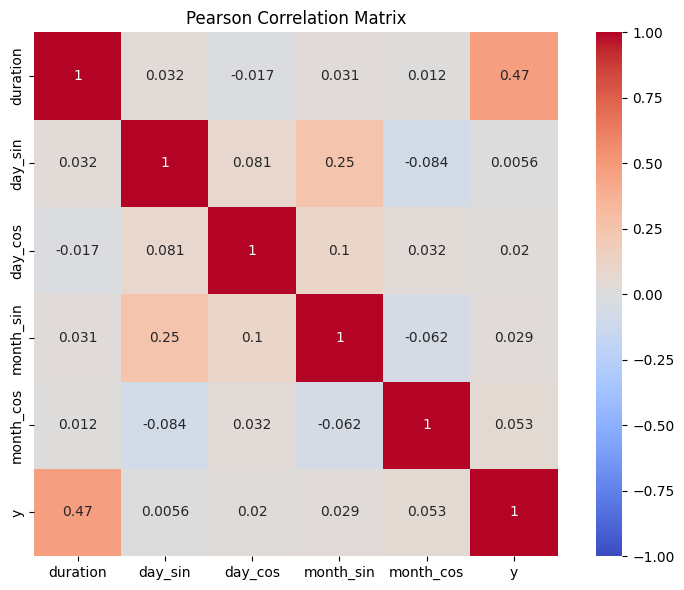

In [20]:
import seaborn as sns

#1. Pearson Correlation: Numerical Feature Selection (duration, day_sin/cos, month_sin/cos)

import matplotlib.pyplot as plt

corr_cols = [
    "duration",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "y"
]

corr_matrix = train_processed_df[corr_cols].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

There is virtually no correlation between month/day sin/cos with y. May not need this at all. This would make preprocessing easier as we wouldn't have to deal with cyclical encoding.

In [21]:
# Chi2 feature selection (categorical)

from scipy.stats import chi2_contingency

exclude_columns = [
    "duration",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "y"
]

cat_columns = [
    col for col in train_processed_df.columns
    if col not in exclude_columns
]

alpha = 0.05
results = []

for col in cat_columns:
    table = pd.crosstab(train_processed_df[col], train_processed_df["y"])
    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "feature": col,
        "chi_square": chi2,
        "p_value": p,
        "degrees_of_freedom": dof,
        "H0_rejected": "yes" if p < alpha else "no"
    })

chi2_results = (
    pd.DataFrame(results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

chi2_results

,feature,chi_square,p_value,degrees_of_freedom,H0_rejected
0,housing,90.240281,2.109239e-21,1,yes
1,education_tertiary,76.384521,2.334742e-18,1,yes
2,marital_married,76.047093,2.769798e-18,1,yes
3,marital_single,65.291490,6.459970e-16,1,yes
4,job_blue-collar,33.382281,7.571062e-09,1,yes
5,education_primary,26.818063,2.235381e-07,1,yes
6,job_student,25.252978,5.028188e-07,1,yes
7,education_secondary,16.967702,3.802115e-05,1,yes
8,job_management,16.107633,5.984236e-05,1,yes
9,job_retired,14.726419,1.242924e-04,1,yes


In [22]:
# It may be worth removing some of the job columns which contribute no info, 4 in total: job_unemployed, job_self-employed, job_entrepeneur, job_technician.

In [23]:
# 3. Cramers V (categorical)

train_data = train_processed_df
target = "y"

cat_columns = [
    col for col in train_data.columns
    if col not in exclude_columns
]

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, c = table.shape
    denom = n * (min(r, c) - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

cramers_v_results = (
    pd.DataFrame(
        [
            {"feature": col, "cramers_v": cramers_v(train_data[col], train_data[target])}
            for col in cat_columns
        ]
    )
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

cramers_v_results

,feature,cramers_v
0,housing,0.058015
1,education_tertiary,0.053376
2,marital_married,0.053258
3,marital_single,0.049348
4,job_blue-collar,0.035286
5,education_primary,0.031627
6,job_student,0.030690
7,education_secondary,0.025157
8,job_management,0.024511
9,job_retired,0.023436


In [24]:
# Cramers V is between 0-1.0. Anythiong less than 0.05 is essentially negligible. I'll use a cut off of ~ 0.01. Based on this, the features flagged during chi_2 evaluation should all be removed.

In [25]:
# 3. Mutual Info (categorical)

from sklearn.feature_selection import mutual_info_classif

exclude_columns = [
    "duration",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "y"
]

cat_columns = [
    col for col in train_data.columns
    if col not in exclude_columns
]

X_cat = train_data[cat_columns]

mi_scores = mutual_info_classif(
    X_cat,
    train_data[target],
    discrete_features=True,
    random_state=13
)

mi_table = (
    pd.DataFrame(
        {
            "feature": cat_columns,
            "mutual_information": mi_scores
        }
    )
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_table


,feature,mutual_information
0,housing,1.656710e-03
1,marital_married,1.398132e-03
2,education_tertiary,1.369037e-03
3,marital_single,1.168375e-03
4,job_blue-collar,6.638860e-04
5,education_primary,5.437341e-04
6,job_student,3.878892e-04
7,education_secondary,3.188933e-04
8,job_management,2.938620e-04
9,job_housemaid,2.637733e-04


In [26]:
# Again, the same 4 'job_' columns appear. I will definitely remove these.

<h4> Creating the new pipeline

Taking the existing pipeline, removing day/month columns + cyclical encoding, doing the engineering, and then removing the obsolete encoded columns (job_technician, job_entrepreneur, job_self-employed, job_unemployed) in a second feature removal component of the pipeline. Also implementing random undersampling rather than SMOTE.